# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [1]:
17

17

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split 
from sklearn.dummy import DummyClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
import warnings
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/Users/pamelatkrueger/Desktop/Berkeley Certificate/Module 17/module17_final/data/bank-additional-full.csv', sep = ';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [11]:
for col in df.columns:
    print(df[col].value_counts(ascending = False))

age
31    1947
32    1846
33    1833
36    1780
35    1759
      ... 
89       2
91       2
94       1
87       1
95       1
Name: count, Length: 78, dtype: int64
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64
housing
yes        21576
no         18622
unknown      990
Name: count, 

Note there are a number of 'unknown' values across the variables

In [5]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


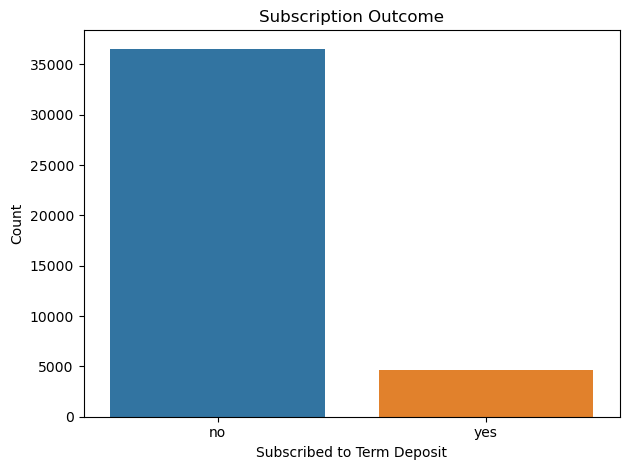

In [4]:
#Visualize class balance of the target variable
class_plot = sns.countplot(data=df, x='y', hue='y')
class_plot.set_title('Subscription Outcome')
class_plot.set_xlabel('Subscribed to Term Deposit')
class_plot.set_ylabel('Count')

plt.tight_layout()
plt.show()


Handling the 'unknown' values

In [12]:
#getting a count of the number of unknowns
unknown_counts = {}
for col in df.select_dtypes(include='object').columns:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        unknown_counts[col] = count

unknowns = pd.DataFrame({'unknowns': unknown_counts})
unknowns.sort_values('unknowns', ascending=False)

,unknowns
default,8597
education,1731
housing,990
loan,990
job,330
marital,80


In [13]:
df['default'].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

The default variable has many unknown values which makes it not very useful in this analysis

Convert the features as follows:

- Target feature 'y' to binary int

- Nominal columns to categorical features

- Ordinal columns to categorical features

- 'pdays' to binary

In [14]:
df_recoded = df.copy()

# Target feature to binary int
df_recoded['y'] = df_recoded['y'].map({'no': 0, 'yes': 1})

# Nominal columns to categorical
nominals = ['job', 'marital', 'contact', 'poutcome', 'default', 'housing', 'loan']
for col in nominals:
    df_recoded[col] = df_recoded[col].astype('category')

# Ordinal columns to categorical
education_order = ['unknown', 'illiterate', 'basic.4y', 'basic.6y', 'basic.9y','high.school', 'professional.course', 'university.degree']
df_recoded['education'] = pd.Categorical(df_recoded['education'], categories=education_order, ordered=True)

# Time columns to categorical
month = ['jan', 'feb', 'mar', 'apr', 'may', 'jun','jul', 'aug', 'sep', 'oct', 'nov', 'dec']
df_recoded['month'] = pd.Categorical(df_recoded['month'], categories=month, ordered=True)

day = ['mon', 'tue', 'wed', 'thu', 'fri']
df_recoded['day_of_week'] = pd.Categorical(df_recoded['day_of_week'], categories=day, ordered=True)

# pdays where 999 is not previously contacted recast to int and new var
df_recoded['was_previously_contacted'] = (df_recoded['pdays'] != 999).astype(int)

df_recoded.dtypes

age                            int64
job                         category
marital                     category
education                   category
default                     category
housing                     category
loan                        category
contact                     category
month                       category
day_of_week                 category
duration                       int64
campaign                       int64
pdays                          int64
previous                       int64
poutcome                    category
emp.var.rate                 float64
cons.price.idx               float64
cons.conf.idx                float64
euribor3m                    float64
nr.employed                  float64
y                              int64
was_previously_contacted       int64
dtype: object

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

The paper mentions that marketing campaigns are ubiquitous (for this bank, but also generally) and thus the effectiveness of them has decreased. They want to know what attributes of potential subscribers lead to a 'yes' subscription to their long-term deposits with good interest rates. They are looking to reduce costs for these campaigns by going after the right applicants who are most likely to subscribe.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

One-hot-encoding

In [15]:
nominals = ['job', 'marital', 'education', 'contact', 'poutcome', 'default', 'housing', 'loan']
ordinals = ['month', 'day_of_week']

#Define feature vector and outcome variable
X = df_recoded.drop(columns='y').copy()
y = df_recoded['y']

# Ordered Categorical features
for col in ordinals:
    X[col] = X[col].cat.codes

# One hot encoding preprocessor
preprocessor = ColumnTransformer(transformers=[('onehot', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False), nominals)],remainder='passthrough')

X_encoded = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

print(X_encoded.shape)
pd.DataFrame(X_encoded, columns=feature_names).head()

(41188, 50)


,onehot__job_admin.,onehot__job_blue-collar,onehot__job_entrepreneur,onehot__job_housemaid,onehot__job_management,onehot__job_retired,onehot__job_self-employed,onehot__job_services,onehot__job_student,onehot__job_technician,...,remainder__duration,remainder__campaign,remainder__pdays,remainder__previous,remainder__emp.var.rate,remainder__cons.price.idx,remainder__cons.conf.idx,remainder__euribor3m,remainder__nr.employed,remainder__was_previously_contacted
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,261.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,149.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,226.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,151.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,307.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0,0.0


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [16]:
features = [c for c in df_recoded.columns if c not in ('y', 'duration')]

X = df_recoded[features]
y = df_recoded['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)
print('X_train', X_train.shape, ' X_test', X_test.shape)

X_train (32950, 20)  X_test (8238, 20)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [17]:
#Build the baseline model
baseline_model = DummyClassifier(strategy='most_frequent', random_state=42)
baseline_model.fit(X_train, y_train)

baseline_train_accuracy = round(baseline_model.score(X_train, y_train),4)
baseline_test_accuracy = round(baseline_model.score(X_test, y_test),4)

print(f'Training accuracy {baseline_train_accuracy}')
print(f'Test accuracy {baseline_test_accuracy}')

Training accuracy 0.8873
Test accuracy 0.8874


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [18]:
#Data Preprocessing
def preprocessor():
    return ColumnTransformer(transformers=[
            ('onehot', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False), nominals),
            ('ordinal', OrdinalEncoder(categories=[month, day]), ordinals)], remainder='passthrough')
#Pipeline build
def pipeline(model):
    return Pipeline([
        ('preprocess', preprocessor()),
        ('scale', StandardScaler()),
        ('model', model)])

lr_pipeline = pipeline(LogisticRegression(max_iter=1000, random_state=42))
lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('scale', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot', ...), ('ordinal', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Problem 9: Score the Model

What is the accuracy of your model?

In [19]:
lr_training_accuracy = round(lr_pipeline.score(X_train, y_train),4)
lr_test_accuracy = round(lr_pipeline.score(X_test, y_test),4)

print(f'Logistic Regression training accuracy {lr_training_accuracy}')
print(f'Logistic Regression test accuracy  {lr_test_accuracy}')

Logistic Regression training accuracy 0.8998
Logistic Regression test accuracy  0.9002


- Our baseline accuracy:
    - Training accuracy 0.8873
    - Test accuracy 0.8874


- Compared to our Logistic Regression accuracy:
    - Logistic Regression training accuracy 0.8998
    - Logistic Regression test accuracy  0.9002

Our logistic regression models fairs better on both training and test accuracy.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [20]:
#Define the models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42)}

results = []
fitted_pipes = {}

#Iterate through the models
for name, model in models.items():
    pipe = pipeline(model)
    t0 = time.time()
    pipe.fit(X_train, y_train)
    #Calculate the training time
    fit_time = time.time() - t0

    fitted_pipes[name] = pipe

    #Append results
    results.append({
        'Model': name,
        'Train Time': round(fit_time, 3),
        'Training Accuracy': round(pipe.score(X_train, y_train), 4),
        'Test Accuracy': round(pipe.score(X_test, y_test), 4)})

#Results to DF
results_df = pd.DataFrame(results).set_index('Model')
results_df

,Train Time,Training Accuracy,Test Accuracy
Model,,,
Logistic Regression,0.199,0.8998,0.9002
KNN,0.079,0.9107,0.8931
Decision Tree,0.210,0.9954,0.8407
SVM,34.348,0.9032,0.9006


We notice the SVM took way more training time than the other models. The decision tree had the highest training accuracy. The highest test accuracy is the SVM, but only slightly higher than logistic regression. But we also discussed accuracy is not a good metric in the lectures.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [22]:
warnings.filterwarnings('ignore', category=UserWarning)

#Set the GridCV parameters for each model type
param_grids = {
    'Logistic Regression': {
        'model__C': [0.01, 0.1, 1, 10],
        'model__class_weight': [None, 'balanced']},
    'KNN': {
        'model__n_neighbors': [5, 11, 21, 31],
        'model__weights': ['uniform', 'distance']},
    'Decision Tree': {
        'model__max_depth': [3, 5, 10, None],
        'model__min_samples_leaf': [1, 5, 20]},
    'SVM': {
        'model__C': [0.1, 1, 10],
        'model__class_weight': ['balanced']}}

X_gridcv, _, y_gridcv, _ = train_test_split(X_train, y_train, train_size=0.25, stratify=y_train, random_state=42)

tuned_results = []
best_estimators = {}

for name, model in models.items():
    pipe = pipeline(model)
    grid = GridSearchCV(pipe, param_grids[name], scoring='roc_auc', cv=3, n_jobs=-1, refit=True)
    t0 = time.time()
    grid.fit(X_gridcv, y_gridcv)
    #Get the model tuning time
    tune_time = time.time() - t0

    #Fit the best hyperparameters on the full training set
    best_params = {k.replace('model__', ''): v for k, v in grid.best_params_.items()}
    model.set_params(**best_params)
    best_estimators[name] = pipeline(model)
    best_estimators[name].fit(X_train, y_train)

    #Append the final results for each model
    tuned_results.append({
        'Model': name,
        'Tune Time': round(tune_time, 1),
        'Best Params': grid.best_params_,
        'CV ROC AUC': round(grid.best_score_, 4),
        'Test Accuracy': round(best_estimators[name].score(X_test, y_test), 4),
    })

tuned_df = pd.DataFrame(tuned_results).set_index('Model')
tuned_df

,Tune Time,Best Params,CV ROC AUC,Test Accuracy
Model,,,,
Logistic Regression,0.3,"{'model__C': 10, 'model__class_weight': 'balan...",0.7679,0.7952
KNN,0.6,"{'model__n_neighbors': 31, 'model__weights': '...",0.7339,0.8991
Decision Tree,0.3,"{'model__max_depth': 5, 'model__min_samples_le...",0.7642,0.9019
SVM,5.6,"{'model__C': 1, 'model__class_weight': 'balanc...",0.7491,0.8275


In [24]:
for name, est in best_estimators.items():
    y_pred = est.predict(X_test)
    if hasattr(est.named_steps['model'], 'predict_proba'):
        y_score = est.predict_proba(X_test)[:, 1]
    else:
        y_score = est.decision_function(X_test)
    auc = roc_auc_score(y_test, y_score)
    print(f'{name} Test ROC AUC: {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['no', 'yes']))

Logistic Regression Test ROC AUC: 0.7933
              precision    recall  f1-score   support

          no       0.95      0.81      0.88      7310
         yes       0.31      0.69      0.43       928

    accuracy                           0.80      8238
   macro avg       0.63      0.75      0.65      8238
weighted avg       0.88      0.80      0.83      8238

KNN Test ROC AUC: 0.7590
              precision    recall  f1-score   support

          no       0.91      0.99      0.95      7310
         yes       0.67      0.20      0.31       928

    accuracy                           0.90      8238
   macro avg       0.79      0.60      0.63      8238
weighted avg       0.88      0.90      0.87      8238

Decision Tree Test ROC AUC: 0.7957
              precision    recall  f1-score   support

          no       0.91      0.98      0.95      7310
         yes       0.67      0.25      0.37       928

    accuracy                           0.90      8238
   macro avg       0.79    

Our baseline accuracy:
- Training accuracy 0.8873
- Test accuracy 0.8874

Accuracy for these various models is not too different from the baseline but this is misleading as was discussed in the lectures.
We want as many subscribers as possible so we would want more false positives. Thus having a high recall is important, so it seems like logistic regression and SVM are good model contenders. But SVM also took much longer to train so possibly logistic regression is the best model here.

Next steps would be to continue trying to adjust the GridSearchCV parameters to see if model performance can continue to be improved.
